# Remote BAX optimization — beginner's guide

**Goal:** Run Bayesian Algorithm Execution (BAX) through the **upstream HTTPGenerator** against an independently started HTTP server. No cloudpickle is required for this example.

**Why client/server?** A scientist can develop a notebook on one machine while the generator runs as a service on another compute node or in a Docker/Kubernetes container. In this example, `sin_function` is evaluated **in Jupyter**, while BAX's candidate-selection work is performed by the **remote generator**. Plotting and model inspection using `pull()` run locally on a downloaded snapshot.

**Development (two processes on lepton):** Start `python -m uvicorn cloudpickle_xopt.server:app --host 127.0.0.1 --port 8002` in a separate terminal; leave it running. Then run this notebook in Jupyter.

**Target (two machines):** Run the server in a container on another node and set `XOPT_HTTP_URL=http://SERVER_HOST:8002` in the Jupyter environment. The container must listen on an accessible interface and the network must permit the connection. Protect the service; do not publicly expose the experimental cloudpickle endpoints.

**Math/physics intuition:** The toy observable is `y1 = sin(x)` with `x` measured in radians between 0 and `2π` (one complete cycle). BAX uses a probabilistic surrogate (a Gaussian process) and an algorithm applied to sampled functions. Its information-gain acquisition seeks measurements that clarify the algorithm's answer, here the position of the minimum, rather than simply picking the lowest predicted value at every step.


**Cell guide — Import the **upstream** HTTPGenerator and select the endpoint. `XOPT_HTTP_URL` can point to a remote Docker/Kubernetes host; otherwise use the local development server on port 8002.


In [1]:
from xopt.generators.remote.http import HTTPGenerator

import os
SERVER_URL = os.environ.get("XOPT_HTTP_URL", "http://127.0.0.1:8002")
print("HTTPGenerator server:", SERVER_URL)

HTTPGenerator server: http://127.0.0.1:8002


## Imports and random seeding for reproducibility

**Cell guide — Import numerical and optimization libraries. PyTorch supplies tensor computations; NumPy and `math` support the sine example; Matplotlib draws the results. Fixed random seeds make runs more comparable, though distributed/numerical details can still vary.


In [2]:
import torch

from xopt import Xopt
from xopt.vocs import VOCS
from xopt.generators.bayesian.bax_generator import BaxGenerator
from xopt.generators.bayesian.bax.algorithms import GridOptimize
from xopt.evaluator import Evaluator
from xopt.generators.bayesian.bax.visualize import visualize_virtual_objective

import numpy as np
import random

import os
import math
import matplotlib.pyplot as plt

# Ignore all warnings
import warnings

warnings.filterwarnings("ignore")


os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

# random seeds for reproducibility
rand_seed = 2

torch.manual_seed(rand_seed)
np.random.seed(rand_seed)  # only affects initial random observations through Xopt
random.seed(rand_seed)

/home/ernesto/controls/package/anaconda3/envs/xopt-http-dev/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## Define the test problem
Here we define a simple optimization problem, where we attempt to minimize the sin
function in the domian [0,2*pi]. Note that the function used to evaluate the
objective function takes a dictionary as input and returns a dictionary as the output.

**Cell guide — Define the Variable–Observable–Constraint–Objective Specification (VOCS). The input `x` spans `0` to `2π` radians; `y1` is an observable. BAX uses an algorithmic target (the minimum found by `GridOptimize`) rather than a direct VOCS objective.


In [3]:
# define variables and function objectives
vocs = VOCS(
    variables={"x": [0, 2 * math.pi]},
    observables=["y1"],
)

**Cell guide — Define the toy “experiment”: for each input `x`, return `sin(x)` as `y1`. This evaluator runs in Jupyter, not on the HTTP server. In an accelerator application it could instead read a measurement from a control system.


In [4]:
# define a test function to optimize
def sin_function(input_dict):
    return {"y1": np.sin(input_dict["x"])}

## Prepare BAX generator for Xopt
Create a generator that uses the ExpectedInformationGain (InfoBAX) acquisition
function to perform Bayesian Optimization. Note that we use minimization on a grid,
so specifying the number of mesh points can negatively impact decision making time
(especially in higher dimensional feature spaces). Note that because we are optimizing a problem with no noise we set `use_low_noise_prior=True` in the GP model constructor.

**Cell guide — Configure `GridOptimize` to look for the minimum on a 50-point grid. `BaxGenerator` uses a Gaussian-process surrogate and information gain to decide which new measurement is most useful. Wrapping it in HTTPGenerator places its suggestion logic on the server.


In [5]:
# Prepare BAX algorithm and generator options
algorithm = GridOptimize(
    observable_names_ordered=["y1"], n_mesh_points=50
)  # NOTE: default is to minimize

# construct BAX generator
bax_generator = BaxGenerator(vocs=vocs, algorithm=algorithm)
bax_generator.gp_constructor.use_low_noise_prior = True

# Only the Generator moves to the HTTP service.
generator = HTTPGenerator(base_url=SERVER_URL, generator=bax_generator)
print("Client wrapper:", type(generator).__name__)

Client wrapper: HTTPGenerator


## Create Evaluator and Xopt objects
Create the Evaluator (which allows Xopt to interface with our test function) and finish constructing our Xopt object.

**Cell guide — Construct the `Evaluator` (runs `sin_function` locally) and the `Xopt` orchestrator (connects evaluation and remote candidate generation).


In [6]:
# construct evaluator
evaluator = Evaluator(function=sin_function)

# construct Xopt optimizer
X = Xopt(evaluator=evaluator, generator=generator)

## Generate and evaluate initial points
To begin optimization, we must generate some random initial data points. The first call
to `X.step()` will generate and evaluate a number of randomly points specified by the
 generator. Note that if we add data to xopt before calling `X.step()` by assigning
 the data to `X.data`, calls to `X.step()` will ignore the random generation and
 proceed to generating points via Bayesian optimization.

**Cell guide — Evaluate three random initial points. Xopt sends those observations to the remote generator to initialize its dataset. Display the notebook-side table to see the measurements.


In [7]:
# evaluate initial points
X.random_evaluate(3)

# inspect the gathered data
X.data

,x,y1,xopt_runtime,xopt_error
0,3.543749,-0.391403,5.215988e-06,False
1,6.120286,-0.162180,1.475913e-06,False
2,2.829554,0.306999,7.089693e-07,False


### Define plotting utility
Define a plotting function that plots the GP model, samples from the GP model, and the
execution paths (red crosses).

**Cell guide — Define a visualization helper. `pull()` retrieves a **snapshot** of the remote generator; GP training, posterior calculations, acquisition evaluation, and plotting below are performed locally on that snapshot. The GP mean is a prediction, the confidence band expresses uncertainty, and the acquisition curve scores useful next measurements.


In [8]:
def plot_bax(X):
    # Pull a fresh read-only snapshot. Everything below (model fitting,
    # acquisition evaluation, and plotting) runs in this Jupyter kernel.
    # The optimization steps themselves still use the remote Generator.
    local_generator = X.generator.pull()
    # get the Gaussian process model from the generator
    model = local_generator.train_model()

    # get acquisition function from generator
    acq = local_generator.get_acquisition(model)

    # calculate model posterior and acquisition function at each test point
    # NOTE: need to add a dimension to the input tensor for evaluating the
    # posterior and another for the acquisition function, see
    # https://botorch.org/docs/batching for details
    # NOTE: we use the `torch.no_grad()` environment to speed up computation by
    # skipping calculations for backpropagation
    with torch.no_grad():
        posterior = model.posterior(test_x.unsqueeze(1))
        acq_val = acq(test_x.reshape(-1, 1, 1))

    # get mean function and confidence regions
    mean = posterior.mean
    L, u = posterior.mvn.confidence_region()

    # plot model and acquisition function
    fig, ax = plt.subplots(3, 1, sharex="all")
    fig.set_size_inches(8, 6)

    # plot model posterior
    ax[0].plot(test_x, mean, label="Posterior mean")
    ax[0].fill_between(test_x, L, u, alpha=0.25, label="Posterior confidence region")

    # add data to model plot
    ax[0].plot(X.data["x"], X.data["y1"], "C1o", label="Training data")

    # plot true function
    true_f = sin_function({"x": test_x})["y1"]
    ax[0].plot(test_x, true_f, "--", label="Ground truth")

    # plot the function samples and their optima found by BAX
    test_points = local_generator.algorithm_results["test_points"]
    posterior_samples = local_generator.algorithm_results["posterior_samples"]
    sample_optima = torch.hstack(
        (
            local_generator.algorithm_results["best_inputs"],
            local_generator.algorithm_results["best_objective"],
        )
    )

    label1 = "Function Samples"
    label2 = "Sample Optima"
    for i in range(local_generator.algorithm.n_samples):
        (samples,) = ax[1].plot(
            test_points, posterior_samples[i], c="C0", alpha=0.3, label=label1
        )
        ax[1].scatter(
            *sample_optima[i], c="r", marker="x", s=80, label=label2, zorder=10
        )
        label1 = None
        label2 = None

    # plot acquisition function
    ax[2].plot(test_x, acq_val.flatten())

    ax[0].set_ylabel("y1")
    ax[1].set_ylabel("y1")
    ax[2].set_ylabel(r"$\alpha(x)$")
    ax[2].set_xlabel("x")

    return fig, ax

## Do bayesian optimization steps
To perform optimization we simply call `X.step()` in a loop. This allows us to do
intermediate tasks in between optimization steps, such as examining the model and
acquisition function at each step (as we demonstrate here).

**Cell guide — Create a grid of `x` values for plotting. Each loop iteration visualizes the current model, then `X.step()` asks the server for a new BAX suggestion, evaluates `sin(x)` in Jupyter, and ingests the result. The existing loop count is retained.


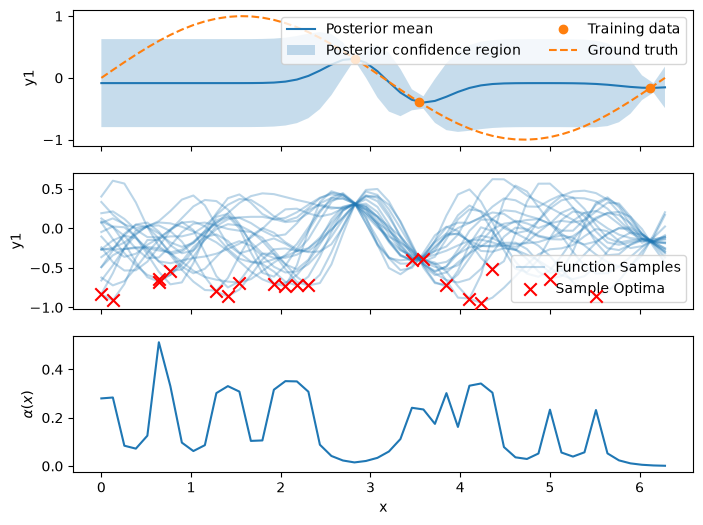

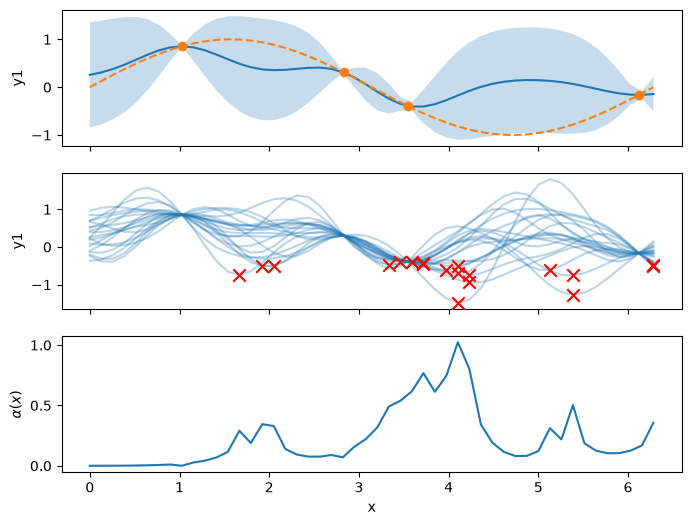

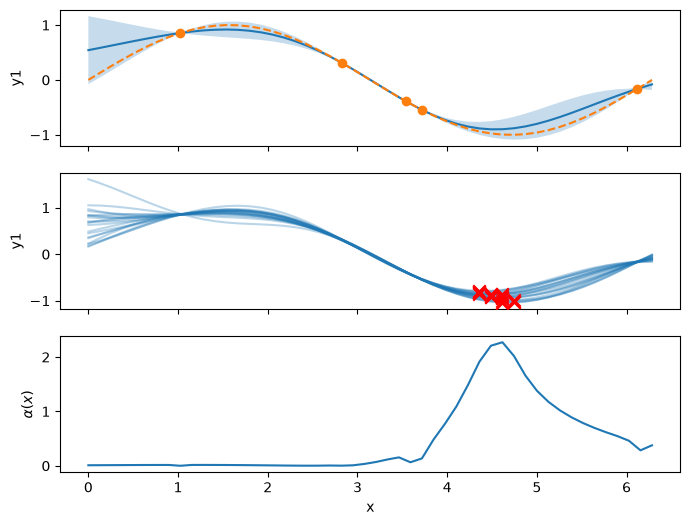

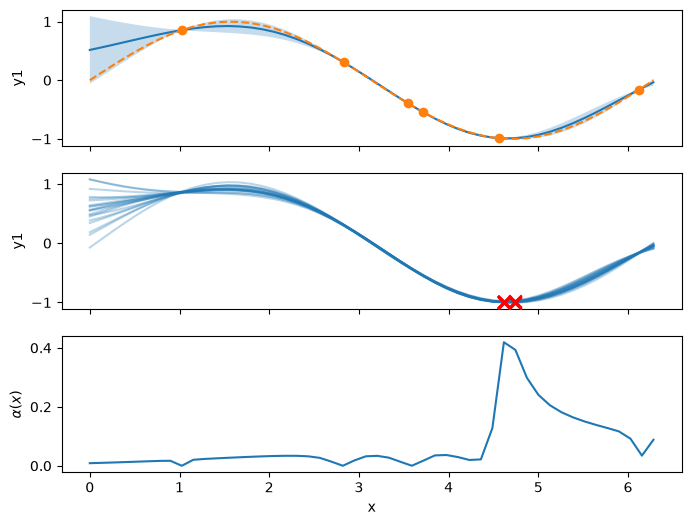

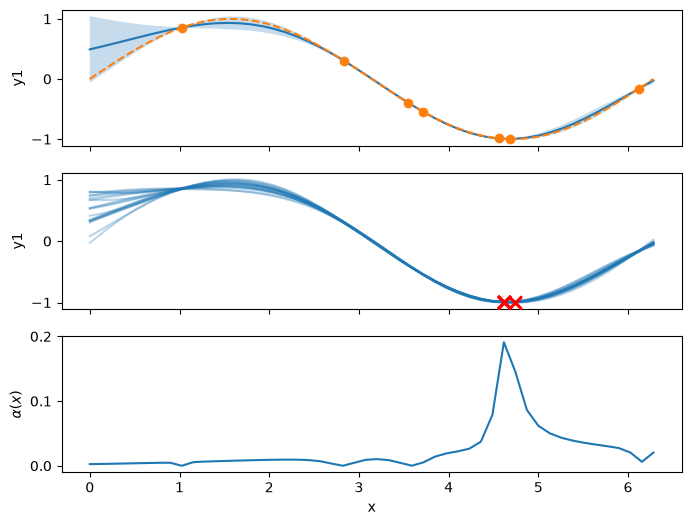

In [9]:
n_steps = 3

# test points for plotting
test_x = torch.linspace(*np.array(X.vocs.bounds).flatten(), 50).double()

for i in range(5):
    # plot model and bax information
    fig, ax = plot_bax(X)

    if i == 0:
        ax[0].legend(ncols=2)
        ax[1].legend()

    # do the optimization step
    X.step()

**Cell guide — Display all measured points collected so far. Compare the values with the sine curve and watch how sampling changes as the model learns.


In [10]:
# access the collected data
X.data

,x,y1,xopt_runtime,xopt_error
0,3.543749,-0.391403,5.215988e-06,False
1,6.120286,-0.162180,1.475913e-06,False
2,2.829554,0.306999,7.089693e-07,False
3,1.025866,0.855163,3.668014e-06,False
4,3.718076,-0.545079,4.429021e-06,False
5,4.560546,-0.988494,4.016911e-06,False
6,4.679165,-0.999448,3.324007e-06,False
7,4.653043,-0.998240,3.661029e-06,False


**Cell guide — Visualize the *virtual objective* from GP posterior samples. In this tutorial, the algorithm seeks the minimum of a sampled function; this is different from plotting only the GP mean. This plot is computed locally using a pulled snapshot.


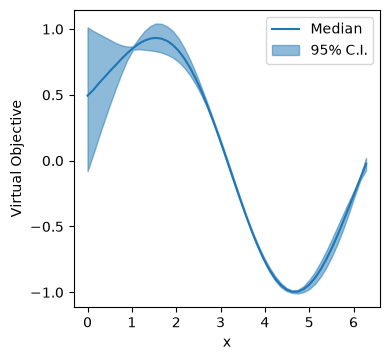

In [11]:
# plot the virtual objective (which in this case is simply the observable model for y1) via posterior sampling

# Visualization is local, using a freshly pulled Generator snapshot.
visualize_virtual_objective(X.generator.pull(), n_samples=1000);

**Cell guide — Finalize the remote BAX session. This removes server-side session state, but the Uvicorn process stays alive for other clients.


In [12]:
# Close the HTTP session when finished. Re-running optimization after this
# cell creates a new remote session from the current local mirror.
X.generator.finalize()
print("Remote BAX session finalized")

Remote BAX session finalized
